n=20 | naive=0.00352100s | cache=0.00005490s | speedup=64.13x
n=25 | naive=0.03065440s | cache=0.00003110s | speedup=985.67x
n=30 | naive=0.25970350s | cache=0.00005270s | speedup=4927.96x


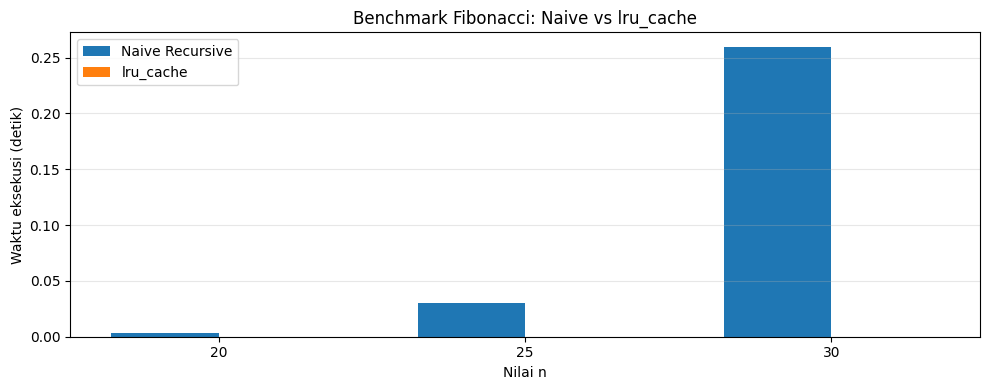

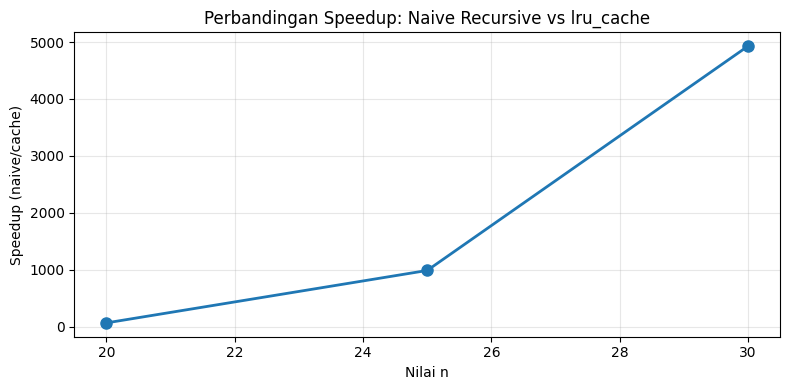

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache

def fib_loop(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

def fib_naive(n):
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

@lru_cache(maxsize=None)
def fib_cache(n):
    if n <= 1:
        return n
    return fib_cache(n - 1) + fib_cache(n - 2)

test_n = [20, 25, 30]
naive_time = []
cache_time = []

for n in test_n:
    fib_cache.cache_clear()

    start = time.perf_counter()
    fib_naive(n)
    t1 = time.perf_counter() - start

    start = time.perf_counter()
    fib_cache(n)
    t2 = time.perf_counter() - start

    naive_time.append(t1)
    cache_time.append(t2)

    speedup = t1 / t2 if t2 > 0 else 0
    print(f"n={n} | naive={t1:.8f}s | cache={t2:.8f}s | speedup={speedup:.2f}x")

# Grafik 1: waktu eksekusi
x = np.arange(len(test_n))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width/2, naive_time, width, label='Naive Recursive')
plt.bar(x + width/2, cache_time, width, label='lru_cache')
plt.xticks(x, test_n)
plt.xlabel('Nilai n')
plt.ylabel('Waktu eksekusi (detik)')
plt.title('Benchmark Fibonacci: Naive vs lru_cache')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Grafik 2: speedup
speedup_vals = [l / c if c > 0 else 0 for l, c in zip(naive_time, cache_time)]

plt.figure(figsize=(8, 4))
plt.plot(test_n, speedup_vals, marker='o', linewidth=2, markersize=8)
plt.xlabel('Nilai n')
plt.ylabel('Speedup (naive/cache)')
plt.title('Perbandingan Speedup: Naive Recursive vs lru_cache')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

loading images...
dataset: (1000, 3072)
train: (700, 3072) test: (300, 3072)
RF train=0.5957s acc=0.6733
SVM train=0.8376s acc=0.7133
SVM better


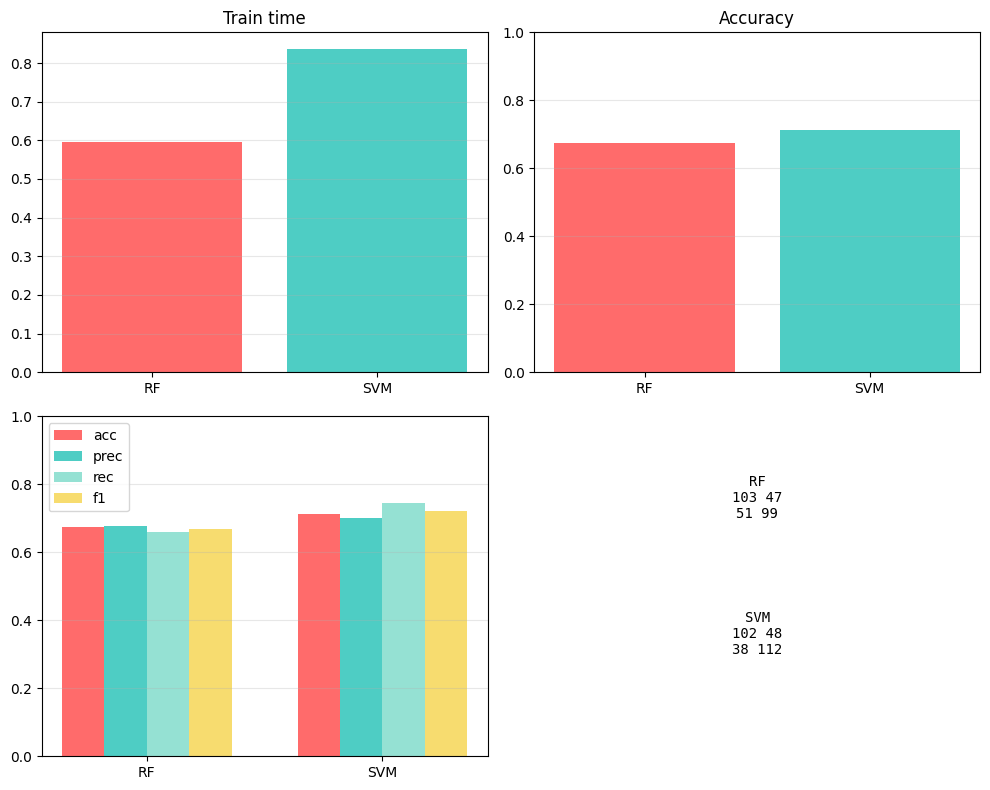

In [4]:
import time
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from pathlib import Path
from PIL import Image
import os

dataset_path = Path(r'c:\Users\LENOVO\Documents\GitHub\university\level-4\perancang-aplikasi-sains-data\tugas\dataset')

def load_images_from_folder(folder_path, label, max_images=None):
    images = []
    labels = []
    count = 0
    
    for file in os.listdir(folder_path):
        if max_images and count >= max_images:
            break
        
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            try:
                img_path = os.path.join(folder_path, file)
                img = Image.open(img_path).convert('RGB')
                img_resized = img.resize((32, 32))
                img_array = np.array(img_resized).flatten()
                
                images.append(img_array)
                labels.append(label)
                count += 1
            except:
                pass
    
    return np.array(images), np.array(labels)

print("loading images...")
X_female, y_female = load_images_from_folder(dataset_path / 'FEMALE', 0, max_images=500)
X_male, y_male = load_images_from_folder(dataset_path / 'MALE', 1, max_images=500)

X = np.vstack([X_female, X_male])
y = np.hstack([y_female, y_male])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"dataset: {X.shape}")
print(f"train: {X_train.shape} test: {X_test.shape}")

start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
t_train_rf = time.time() - start

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RF train={t_train_rf:.4f}s acc={acc_rf:.4f}")

start = time.time()
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
t_train_svm = time.time() - start

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM train={t_train_svm:.4f}s acc={acc_svm:.4f}")

if acc_svm > acc_rf:
    print("SVM better")
else:
    print("RF better")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

algo = ['RF', 'SVM']
axes[0, 0].bar(algo, [t_train_rf, t_train_svm], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Train time')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(algo, [acc_rf, acc_svm], color=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

x_pos = np.arange(len(algo))
w = 0.18
axes[1, 0].bar(x_pos-1.5*w, [acc_rf, acc_svm], w, label='acc', color='#FF6B6B')
axes[1, 0].bar(x_pos-0.5*w, [prec_rf, prec_svm], w, label='prec', color='#4ECDC4')
axes[1, 0].bar(x_pos+0.5*w, [rec_rf, rec_svm], w, label='rec', color='#95E1D3')
axes[1, 0].bar(x_pos+1.5*w, [f1_rf, f1_svm], w, label='f1', color='#F7DC6F')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(algo)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)
axes[1, 1].text(0.5, 0.7, f"RF\n{cm_rf[0,0]} {cm_rf[0,1]}\n{cm_rf[1,0]} {cm_rf[1,1]}", 
                ha='center', fontsize=10, family='monospace')
axes[1, 1].text(0.5, 0.3, f"SVM\n{cm_svm[0,0]} {cm_svm[0,1]}\n{cm_svm[1,0]} {cm_svm[1,1]}", 
                ha='center', fontsize=10, family='monospace')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()